# Finite Difference Methods for Simulation & Numerical Methods

This notebook covers the foundation of numerical differentiation and the finite difference solution of differential equations:

1. **Numerical Differentiation** — forward, backward, and central differences with error analysis
2. **Ordinary Differential Equations (ODEs)** — Euler, Improved Euler, and Runge-Kutta 4
3. **Partial Differential Equations (PDEs)**:
   - **Heat equation** (parabolic): explicit time stepping
   - **Wave equation** (hyperbolic): second-order time stepping with CFL stability
   - **Laplace equation** (elliptic): iterative relaxation (Jacobi method)

We visualize convergence rates, stability constraints, and solution behavior using only **numpy** and **matplotlib**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11


## 1. Numerical Differentiation

For a smooth function $f(x)$, Taylor expansions yield approximations to $f'(x)$:

- **Forward difference:** $f'(x) \approx \frac{f(x+h) - f(x)}{h}, \quad O(h)$
- **Backward difference:** $f'(x) \approx \frac{f(x) - f(x-h)}{h}, \quad O(h)$
- **Central difference:** $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}, \quad O(h^2)$

The truncation error comes from the neglected higher-order terms. For central differences, the first-order terms cancel, leaving an error proportional to $h^2$.


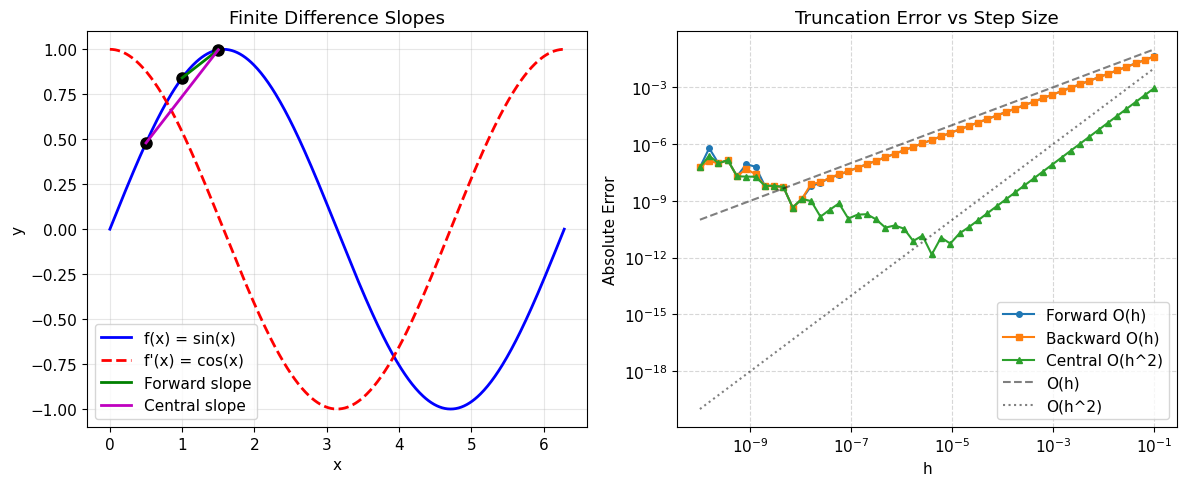

In [2]:
def f(x):
    return np.sin(x)

def df_exact(x):
    return np.cos(x)

x0 = 1.0
h_vals = np.logspace(-10, -1, 50)

err_forward = []
err_backward = []
err_central = []

for h in h_vals:
    df_fwd = (f(x0 + h) - f(x0)) / h
    df_bwd = (f(x0) - f(x0 - h)) / h
    df_cnt = (f(x0 + h) - f(x0 - h)) / (2.0 * h)
    err_forward.append(abs(df_fwd - df_exact(x0)))
    err_backward.append(abs(df_bwd - df_exact(x0)))
    err_central.append(abs(df_cnt - df_exact(x0)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_plot = np.linspace(0, 2*np.pi, 500)
axes[0].plot(x_plot, f(x_plot), 'b-', lw=2, label='f(x) = sin(x)')
axes[0].plot(x_plot, df_exact(x_plot), 'r--', lw=2, label="f'(x) = cos(x)")

h_demo = 0.5
x_demo = np.array([x0 - h_demo, x0, x0 + h_demo])
y_demo = f(x_demo)
axes[0].plot(x_demo, y_demo, 'ko', markersize=8)
axes[0].plot([x0, x0 + h_demo], [f(x0), f(x0 + h_demo)], 'g-', lw=2, label='Forward slope')
axes[0].plot([x0 - h_demo, x0 + h_demo], [f(x0 - h_demo), f(x0 + h_demo)], 'm-', lw=2, label='Central slope')
axes[0].set_title('Finite Difference Slopes')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].loglog(h_vals, err_forward, 'o-', label='Forward O(h)', markersize=4)
axes[1].loglog(h_vals, err_backward, 's-', label='Backward O(h)', markersize=4)
axes[1].loglog(h_vals, err_central, '^-', label='Central O(h^2)', markersize=4)
axes[1].loglog(h_vals, h_vals, 'k--', alpha=0.5, label='O(h)')
axes[1].loglog(h_vals, h_vals**2, 'k:', alpha=0.5, label='O(h^2)')
axes[1].set_title('Truncation Error vs Step Size')
axes[1].set_xlabel('h')
axes[1].set_ylabel('Absolute Error')
axes[1].legend()
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 2. Solving ODEs: Euler and Runge-Kutta Methods

Consider the initial value problem:
$$\frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0$$

**Explicit Euler:**
$$y_{n+1} = y_n + h \, f(t_n, y_n), \quad O(h)$$

**Improved Euler (Heun's method):**
$$\tilde{y} = y_n + h \, f(t_n, y_n)$$
$$y_{n+1} = y_n + \frac{h}{2}\left[f(t_n, y_n) + f(t_{n+1}, \tilde{y})\right], \quad O(h^2)$$

**Classical Runge-Kutta 4 (RK4):**
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4), \quad O(h^4)$$

We test on the model problem $y' = -y$ with exact solution $y(t) = e^{-t}$.


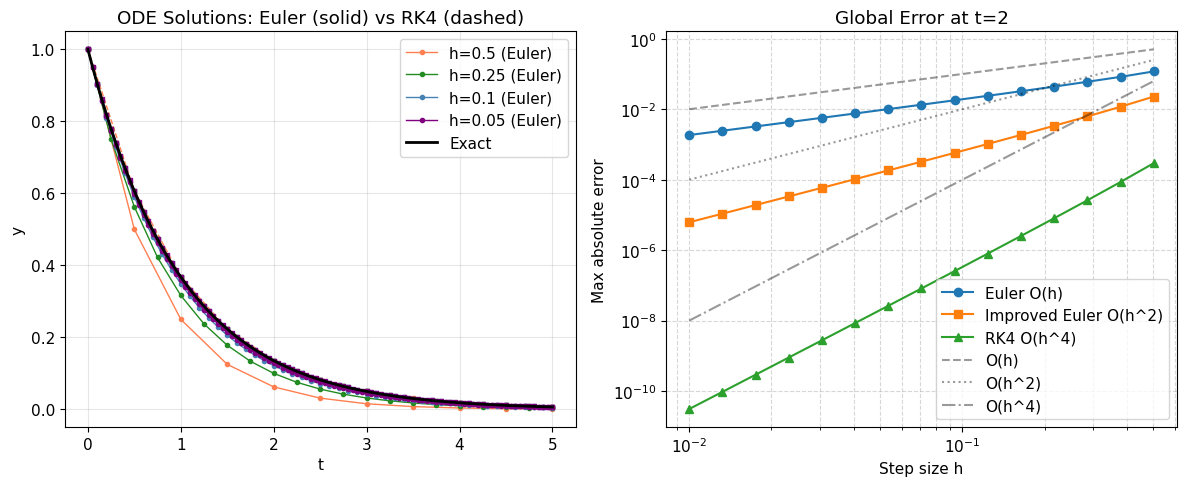

In [3]:
def f_ode(t, y):
    return -y

def exact_ode(t):
    return np.exp(-t)

def euler(f, y0, t):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        y[i+1] = y[i] + h * f(t[i], y[i])
    return y

def improved_euler(f, y0, t):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = f(t[i], y[i])
        y_pred = y[i] + h * k1
        k2 = f(t[i+1], y_pred)
        y[i+1] = y[i] + 0.5 * h * (k1 + k2)
    return y

def rk4(f, y0, t):
    y = np.zeros(len(t))
    y[0] = y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = f(t[i], y[i])
        k2 = f(t[i] + 0.5*h, y[i] + 0.5*h*k1)
        k3 = f(t[i] + 0.5*h, y[i] + 0.5*h*k2)
        k4 = f(t[i] + h, y[i] + h*k3)
        y[i+1] = y[i] + (h/6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return y

# Solve
t_fine = np.linspace(0, 5, 500)
y_exact = exact_ode(t_fine)

h_list = [0.5, 0.25, 0.1, 0.05]
colors = ['coral', 'forestgreen', 'steelblue', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for h, c in zip(h_list, colors):
    t_coarse = np.arange(0, 5 + h, h)
    y_eu = euler(f_ode, 1.0, t_coarse)
    y_ie = improved_euler(f_ode, 1.0, t_coarse)
    y_rk = rk4(f_ode, 1.0, t_coarse)
    axes[0].plot(t_coarse, y_eu, 'o-', color=c, lw=1, markersize=3, label='h={} (Euler)'.format(h))
    axes[0].plot(t_coarse, y_rk, 's--', color=c, lw=1, markersize=3)

axes[0].plot(t_fine, y_exact, 'k-', lw=2, label='Exact')
axes[0].set_title('ODE Solutions: Euler (solid) vs RK4 (dashed)')
axes[0].set_xlabel('t')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Convergence plot
h_conv = np.logspace(-2, -0.3, 15)
err_eu = []
err_ie = []
err_rk = []
for h in h_conv:
    t_test = np.arange(0, 2.0 + h, h)
    y_e = euler(f_ode, 1.0, t_test)
    y_i = improved_euler(f_ode, 1.0, t_test)
    y_r = rk4(f_ode, 1.0, t_test)
    y_true = exact_ode(t_test)
    err_eu.append(np.max(np.abs(y_e - y_true)))
    err_ie.append(np.max(np.abs(y_i - y_true)))
    err_rk.append(np.max(np.abs(y_r - y_true)))

axes[1].loglog(h_conv, err_eu, 'o-', label='Euler O(h)')
axes[1].loglog(h_conv, err_ie, 's-', label='Improved Euler O(h^2)')
axes[1].loglog(h_conv, err_rk, '^-', label='RK4 O(h^4)')
axes[1].loglog(h_conv, h_conv, 'k--', alpha=0.4, label='O(h)')
axes[1].loglog(h_conv, h_conv**2, 'k:', alpha=0.4, label='O(h^2)')
axes[1].loglog(h_conv, h_conv**4, 'k-.', alpha=0.4, label='O(h^4)')
axes[1].set_title('Global Error at t=2')
axes[1].set_xlabel('Step size h')
axes[1].set_ylabel('Max absolute error')
axes[1].legend()
axes[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 3. The Heat Equation (Parabolic PDE)

We solve the 1D heat equation:
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, L], \; t > 0$$

with initial condition $u(x, 0) = \sin(\pi x / L)$ and Dirichlet boundary conditions $u(0, t) = u(L, t) = 0$.

**Explicit finite difference scheme:**
$$u_j^{n+1} = u_j^n + r \left(u_{j+1}^n - 2u_j^n + u_{j-1}^n\right)$$

where $r = \alpha \Delta t / (\Delta x)^2$.

**Von Neumann stability analysis** shows this scheme is **stable only if**:
$$r \leq \frac{1}{2}$$

We demonstrate both a stable and an unstable choice of parameters.


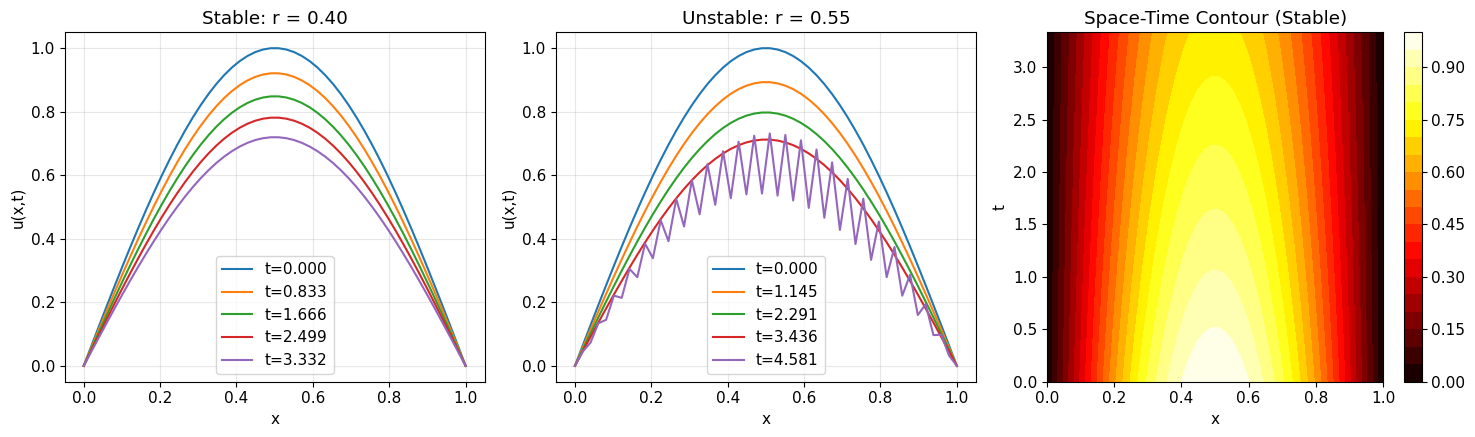

Stable dt = 0.016660, r = 0.400
Unstable dt = 0.022907, r = 0.550


In [4]:
def heat_explicit(u0, alpha, dx, dt, nt, r):
    nx = len(u0)
    u = u0.copy()
    u_all = [u.copy()]
    for n in range(nt):
        u_new = u.copy()
        for j in range(1, nx - 1):
            u_new[j] = u[j] + r * (u[j+1] - 2.0*u[j] + u[j-1])
        u_new[0] = 0.0
        u_new[-1] = 0.0
        u = u_new
        u_all.append(u.copy())
    return np.array(u_all)

L = 1.0
nx = 50
x = np.linspace(0, L, nx)
u0 = np.sin(np.pi * x / L)
alpha = 0.01

dx = x[1] - x[0]
dt_stable = 0.4 * dx**2 / alpha   # r = 0.4 < 0.5
dt_unstable = 0.55 * dx**2 / alpha  # r = 0.55 > 0.5
nt = 200

r_stable = alpha * dt_stable / dx**2
r_unstable = alpha * dt_unstable / dx**2

u_stable = heat_explicit(u0, alpha, dx, dt_stable, nt, r_stable)
u_unstable = heat_explicit(u0, alpha, dx, dt_unstable, nt, r_unstable)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Snapshots stable
t_snap = [0, 50, 100, 150, 200]
for n in t_snap:
    axes[0].plot(x, u_stable[n], label='t={:.3f}'.format(n*dt_stable))
axes[0].set_title('Stable: r = {:.2f}'.format(r_stable))
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x,t)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Snapshots unstable
for n in t_snap:
    if n < len(u_unstable):
        axes[1].plot(x, u_unstable[n], label='t={:.3f}'.format(n*dt_unstable))
axes[1].set_title('Unstable: r = {:.2f}'.format(r_unstable))
axes[1].set_xlabel('x')
axes[1].set_ylabel('u(x,t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Space-time contour (stable)
T_grid = np.arange(0, (nt+1)*dt_stable, dt_stable)[:len(u_stable)]
X_grid, T_grid_mesh = np.meshgrid(x, T_grid)
cont = axes[2].contourf(X_grid, T_grid_mesh, u_stable, levels=20, cmap='hot')
axes[2].set_title('Space-Time Contour (Stable)')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(cont, ax=axes[2])

plt.tight_layout()
plt.show()

print("Stable dt = {:.6f}, r = {:.3f}".format(dt_stable, r_stable))
print("Unstable dt = {:.6f}, r = {:.3f}".format(dt_unstable, r_unstable))


## 4. The Wave Equation (Hyperbolic PDE)

We solve the 1D wave equation:
$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}, \quad x \in [0, L]$$

with initial displacement $u(x, 0) = f(x)$ and zero initial velocity $u_t(x, 0) = 0$, plus fixed boundaries $u(0, t) = u(L, t) = 0$.

**Finite difference scheme:**
$$u_j^{n+1} = 2u_j^n - u_j^{n-1} + \lambda^2 \left(u_{j+1}^n - 2u_j^n + u_{j-1}^n\right)$$

where $\lambda = c \Delta t / \Delta x$ is the Courant number.

**CFL stability condition:** $\lambda \leq 1$.

The first step is initialized using the zero-velocity condition:
$$u_j^1 = u_j^0 + \frac{\lambda^2}{2}\left(u_{j+1}^0 - 2u_j^0 + u_{j-1}^0\right)$$


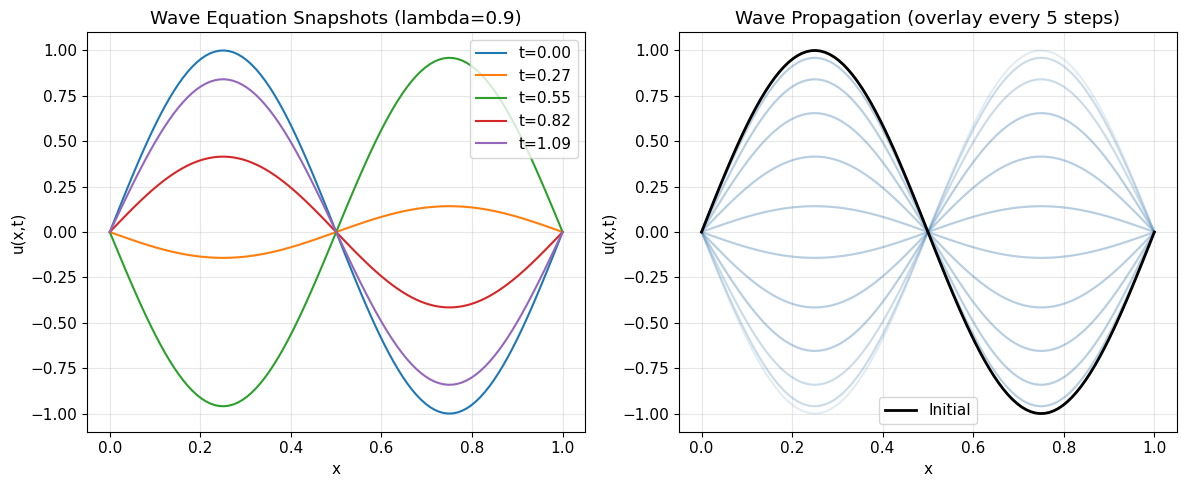

Courant number lambda = 0.900


In [5]:
def wave_eq(u0, c, dx, dt, nt, lam):
    nx = len(u0)
    u_prev = u0.copy()
    u_curr = u0.copy()
    # First step with zero initial velocity
    for j in range(1, nx - 1):
        u_curr[j] = u0[j] + 0.5 * lam**2 * (u0[j+1] - 2.0*u0[j] + u0[j-1])
    u_curr[0] = 0.0
    u_curr[-1] = 0.0
    
    u_all = [u0.copy(), u_curr.copy()]
    
    for n in range(1, nt):
        u_next = np.zeros(nx)
        for j in range(1, nx - 1):
            u_next[j] = 2.0*u_curr[j] - u_prev[j] + lam**2 * (u_curr[j+1] - 2.0*u_curr[j] + u_curr[j-1])
        u_next[0] = 0.0
        u_next[-1] = 0.0
        u_prev = u_curr.copy()
        u_curr = u_next.copy()
        u_all.append(u_curr.copy())
    return np.array(u_all)

L = 1.0
nx = 100
x = np.linspace(0, L, nx)
u0_wave = np.sin(2.0 * np.pi * x / L)
c = 1.0
dx = x[1] - x[0]

# Stable: lambda = 0.9
dt_stable_w = 0.9 * dx / c
lam_stable = c * dt_stable_w / dx
nt_w = 150

u_wave = wave_eq(u0_wave, c, dx, dt_stable_w, nt_w, lam_stable)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

snap_times = [0, 30, 60, 90, 120]
for n in snap_times:
    axes[0].plot(x, u_wave[n], label='t={:.2f}'.format(n*dt_stable_w))
axes[0].set_title('Wave Equation Snapshots (lambda={:.1f})'.format(lam_stable))
axes[0].set_xlabel('x')
axes[0].set_ylabel('u(x,t)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Animated-style overlay with alpha
for n in range(0, nt_w+1, 5):
    axes[1].plot(x, u_wave[n], alpha=0.15, color='steelblue')
axes[1].plot(x, u0_wave, 'k-', lw=2, label='Initial')
axes[1].set_title('Wave Propagation (overlay every 5 steps)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('u(x,t)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Courant number lambda = {:.3f}".format(lam_stable))


## 5. Laplace Equation (Elliptic PDE)

We solve the 2D Laplace equation on the unit square:
$$\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} = 0, \quad (x, y) \in [0, 1]^2$$

with boundary conditions:
- $u(x, 0) = 0$, $u(x, 1) = \sin(\pi x)$
- $u(0, y) = 0$, $u(1, y) = 0$

**Five-point stencil:**
$$u_{i,j} = \frac{1}{4}\left(u_{i+1,j} + u_{i-1,j} + u_{i,j+1} + u_{i,j-1}\right)$$

**Jacobi iteration** updates every interior point simultaneously using values from the previous iteration. The method converges, though slowly; SOR (Successive Over-Relaxation) would accelerate it.


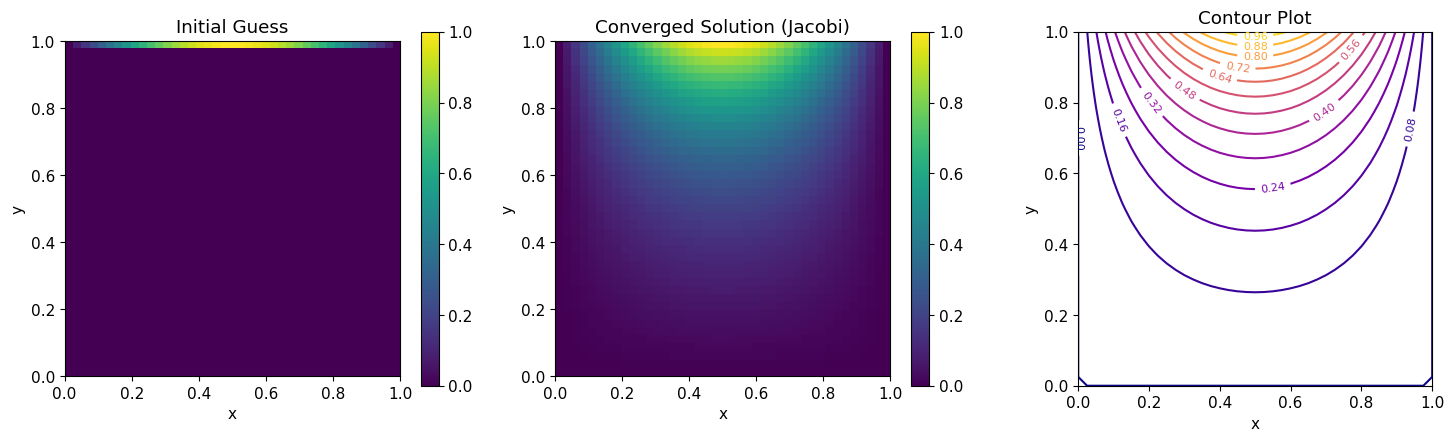

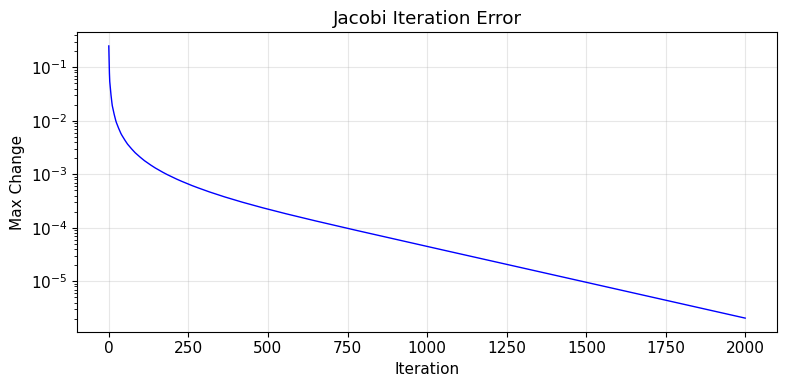

Iterations to convergence: 2000
Final max residual: 2.05e-06


In [6]:
def solve_laplace_jacobi(nx, ny, max_iter=2000, tol=1e-6):
    u = np.zeros((ny, nx))
    x = np.linspace(0, 1, nx)
    y = np.linspace(0, 1, ny)
    
    # Boundary conditions
    u[-1, :] = np.sin(np.pi * x)  # top
    u[0, :] = 0.0                  # bottom
    u[:, 0] = 0.0                  # left
    u[:, -1] = 0.0                 # right
    
    u_history = [u.copy()]
    errors = []
    
    for it in range(max_iter):
        u_new = u.copy()
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                u_new[i, j] = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
        # Re-apply BC
        u_new[-1, :] = np.sin(np.pi * x)
        u_new[0, :] = 0.0
        u_new[:, 0] = 0.0
        u_new[:, -1] = 0.0
        
        err = np.max(np.abs(u_new - u))
        errors.append(err)
        u = u_new
        if it % 200 == 0:
            u_history.append(u.copy())
        if err < tol:
            break
    
    return u, x, y, u_history, errors

u_sol, x_lap, y_lap, u_hist, err_hist = solve_laplace_jacobi(41, 41, max_iter=2000, tol=1e-6)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Initial guess
im0 = axes[0].imshow(u_hist[0], extent=[0, 1, 0, 1], origin='lower', cmap='viridis', aspect='equal')
axes[0].set_title('Initial Guess')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0])

# Final solution
im1 = axes[1].imshow(u_sol, extent=[0, 1, 0, 1], origin='lower', cmap='viridis', aspect='equal')
axes[1].set_title('Converged Solution (Jacobi)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im1, ax=axes[1])

# Contour lines
X_lap, Y_lap = np.meshgrid(x_lap, y_lap)
cs = axes[2].contour(X_lap, Y_lap, u_sol, levels=15, cmap='plasma')
axes[2].clabel(cs, inline=True, fontsize=8)
axes[2].set_title('Contour Plot')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

# Convergence curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(err_hist, 'b-', lw=1)
ax.set_title('Jacobi Iteration Error')
ax.set_xlabel('Iteration')
ax.set_ylabel('Max Change')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Iterations to convergence: {}".format(len(err_hist)))
print("Final max residual: {:.2e}".format(err_hist[-1]))


## Summary

| Method | Equation Type | Scheme | Stability | Error Order |
|--------|--------------|--------|-----------|-------------|
| **Forward Diff** | Derivative | $(f(x+h)-f(x))/h$ | N/A | $O(h)$ |
| **Central Diff** | Derivative | $(f(x+h)-f(x-h))/(2h)$ | N/A | $O(h^2)$ |
| **Explicit Euler** | ODE | $y_{n+1} = y_n + h f_n$ | Conditionally stable | $O(h)$ |
| **RK4** | ODE | Weighted average of 4 slopes | Conditionally stable | $O(h^4)$ |
| **Explicit FTCS** | Heat eq. | Forward time, centered space | $r \leq 0.5$ | $O(\Delta t) + O(\Delta x^2)$ |
| **Leapfrog** | Wave eq. | Centered time, centered space | CFL: $\lambda \leq 1$ | $O(\Delta t^2) + O(\Delta x^2)$ |
| **Jacobi** | Laplace eq. | 5-point stencil relaxation | Unconditionally stable (iterative) | $O(\Delta x^2)$ |

### Key Takeaways
1. **Consistency** + **Stability** = **Convergence** (Lax Equivalence Theorem for linear PDEs).
2. Explicit schemes are simple but constrained by stability; implicit schemes (Crank-Nicolson, backward Euler) allow larger time steps at the cost of solving linear systems.
3. The CFL condition and von Neumann analysis are essential tools for designing stable finite difference schemes.
4. For elliptic problems, iterative relaxation converges but may require thousands of iterations; multigrid or SOR dramatically accelerates convergence.
5. 